# アカウントモデルとEVM

ここではEthereumの実行レイヤー（Execution Layer）の仕組みを、アカウント → トランザクション → 実行 → ブロックの順に見ていく。合意形成（PoS）については [Proof of Stake](./proof_of_stake.ipynb) を参照。

## アカウント

Ethereumには2種類のアカウントがある。どちらも20バイトのアドレスで識別され、アドレスを見ただけではどちらの種類か区別できない。

| | EOA（Externally Owned Account） | CA（Contract Account） |
| --- | --- | --- |
| 管理者 | 人（またはブロックチェーン外のソフトウェア） | なし（ブロックチェーン上のプログラム） |
| 秘密鍵 | あり | なし |
| コード | なし | あり（スマートコントラクトのバイトコード） |
| トランザクションの発行 | できる | できない（EOAからの呼び出しを起点に、他のコントラクトを呼ぶことはできる） |

:::{note}
2025年のPectraアップグレードで導入されたEIP-7702により、EOAが一時的にコントラクトのコードを委任先として設定できるようになり、両者の境界は曖昧になりつつある（→ アカウント抽象化）。
:::

### アドレスの導出

- **EOA**：秘密鍵 → 公開鍵（secp256k1、Bitcoinと同じ）→ 公開鍵（64バイト）のKeccak-256ハッシュの **末尾20バイト**。Bitcoinと違いBase58Checkは使わず、`0x` + 16進数40桁で表す。大文字・小文字の混在でチェックサムを表現する方式（EIP-55）がある
- **CA（CREATEの場合）**：デプロイしたアカウントのアドレスと、その時点のnonceをRLPエンコードしてKeccak-256した末尾20バイト
- **CA（CREATE2の場合）**：デプロイ者のアドレス、任意のsalt、コードのハッシュから計算。デプロイ前にアドレスを予測できる

:::{note}
EthereumのKeccak-256は、NISTが標準化したSHA3-256とはパディングが異なり、出力も異なる。Pythonの `hashlib.sha3_256` はSHA3-256なので、Ethereumのハッシュ計算には使えない。
:::

### ワールドステート

Ethereumは、全アカウントの状態の集まりである **ワールドステート（world state）** を管理する。トランザクションはワールドステートを遷移させる関数と見なせる。

$$
\sigma_{t+1} = \Upsilon(\sigma_t, T)
$$

各アカウントは次の4つのフィールドを持つ。

| フィールド | EOA | CA |
| --- | --- | --- |
| nonce | 送信したトランザクション数 | 作成したコントラクト数 |
| balance | ETH残高（wei） | ETH残高（wei） |
| codeHash | 空のハッシュ | コントラクトのバイトコードのハッシュ |
| storageRoot | 空 | コントラクトの変数を格納したストレージのルートハッシュ |

ワールドステートとストレージは **マークル・パトリシア・トライ（Merkle Patricia Trie, MPT）** に格納される。MPTはキーで値を検索できるトライ（パトリシア木）にマークルツリーのハッシュを組み合わせたもので、

- アドレス（のハッシュ）をキーにアカウントを効率的に検索・更新できる
- ルートハッシュ（stateRoot）だけで全状態を要約でき、任意のアカウントの状態をマークルプルーフで証明できる

という性質を持つ。

### フローとストック

ブロックチェーンに記録されるのはトランザクション（フロー）で、その実行結果であるステート（ストック）自体はブロックの外、各フルノードのデータベースに保持される。ブロックにはステートの要約であるstateRootだけが記録される。

Bitcoinはフロー（UTXO形式のトランザクション）だけでシステムを成立させていたのに対し、Ethereumはストックも管理している点が大きな違い。

## トランザクション

### 2種類の操作

EOAが送るトランザクションは、操作の種類で2つに分けられる。

- **コントラクト作成（contract creation）**：宛先を空にし、`data` にコントラクトの初期化コードを入れて送る。コントラクトをブロックチェーン上で使えるようにすることを **デプロイ** と呼ぶ
- **メッセージコール（message call）**：EOAへの送金、またはコントラクトの関数呼び出し

どちらも、mempoolにあるうちはまだ実行されておらず、ブロックに取り込まれて初めて実行される。

### トランザクションのフィールド（EIP-1559形式）

| フィールド | 内容 |
| --- | --- |
| chain_id | チェーンの識別子（メインネットは1）。別チェーンでのリプレイを防ぐ |
| nonce | 送信者にとって何番目のトランザクションか。同じトランザクションの二重実行を防ぐ |
| max_priority_fee_per_gas | ブロック提案者へのチップの上限（gasあたり） |
| max_fee_per_gas | 支払うgas単価の上限 |
| gas_limit | このトランザクションに使ってよいgasの上限 |
| to | 宛先アドレス（EOAまたはCA） |
| value | 送金するETHの量（wei） |
| data | コントラクトに渡す関数セレクタと引数（calldata） |
| access_list | 事前にアクセスを宣言するアドレスとストレージ（EIP-2930） |
| v, r, s | ECDSA署名 |

送信元アドレスはトランザクションに含まれず、署名から復元する。

| 例 | to | value | data |
| --- | --- | --- | --- |
| Aさんに3 ETH送金 | AさんのEOA | 3 ETH | 空 |
| ERC-20トークンを5枚送る | トークンのCA | 0 | `transfer(Aさんのアドレス, 5)` をエンコードしたもの |

トランザクションは **RLP（Recursive Length Prefix）** という方式でバイト列にシリアライズされる。トランザクションの種類は先頭の1バイトで区別する（EIP-2718）。

| タイプ | 名称 | 導入 |
| --- | --- | --- |
| 0 | Legacy | 初期 |
| 1 | Access list（EIP-2930） | Berlin（2021） |
| 2 | Dynamic fee（EIP-1559） | London（2021） |
| 3 | Blob（EIP-4844） | Dencun（2024） |
| 4 | Set code（EIP-7702） | Pectra（2025） |

## Gas

### gasとは

Ethereumはチューリング完全なので、無限ループするプログラムも書けてしまう。そこで、EVMの命令（オペコード）ごとに計算コストを **gas** という単位で定め、実行した分のgas代を送信者に支払わせる。これにより

- 無限ループや重い処理でネットワークを止める攻撃を防ぐ（停止性問題を経済的に回避する）
- ブロック提案者に報酬を与える

ことができる。

トラックの運送に例えると、gasはガソリンの量、gas単価（fee per gas）はガソリンのリッター価格、gas limitは積んでおくガソリンの上限にあたる。

主なオペコードのgasコスト（[evm.codes](https://www.evm.codes/) で一覧できる）：

| 操作 | gas | 備考 |
| --- | --- | --- |
| ADD, SUB | 3 | |
| MUL, DIV | 5 | |
| KECCAK256 | 30 + 6/ワード | |
| SLOAD | 2,100（cold）/ 100（warm） | トランザクション内で初回アクセスかどうか（EIP-2929） |
| SSTORE | 最大22,100 | ゼロから非ゼロへの書き込みが最も高い |
| CALL | 2,600（cold）/ 100（warm）+ α | |
| CREATE | 32,000 | |
| LOG | 375 + 375/トピック + 8/バイト | |

ストレージへの書き込みは、全フルノードが永続的に保持する必要があるため非常に高い。

### 手数料の計算（EIP-1559）

2021年のLondonアップグレード以降、gas単価は2つの部分からなる。

$$
\text{fee per gas} = \text{base fee per gas} + \text{priority fee per gas}
$$

$$
\text{手数料} = \text{fee per gas} \times \text{gas used}
$$

| 要素 | 決め方 | 行き先 |
| --- | --- | --- |
| base fee | プロトコルがブロックの混雑度から自動で決める | **焼却（burn）** される |
| priority fee（チップ） | 送信者が決める | ブロック提案者の報酬 |

実際には送信者は `max_fee_per_gas` と `max_priority_fee_per_gas` を指定し、

$$
\text{priority fee} = \min(\text{max priority fee},\ \text{max fee} - \text{base fee})
$$

となる。

base feeは、直前のブロックの使用gasがターゲット（ブロックgas上限の半分）をどれだけ上回ったかで、ブロックごとに最大12.5%ずつ上下する。

$$
b_{t+1} = b_t \left(1 + \frac{1}{8} \cdot \frac{g_t - g^*}{g^*}\right)
$$

ここで $g_t$ はブロック $t$ の使用gas、$g^*$ はターゲット。ブロックが満杯（$g_t = 2g^*$）なら12.5%上昇し、空なら12.5%下落する。

base feeを焼却することで、

- 提案者が自分でトランザクションを詰めて手数料を吊り上げる誘因をなくす
- 手数料の見積もりがしやすくなる（オークションで競り合う必要が減る）
- ネットワークの利用が多いとETHの供給が減る（発行量より焼却量が多ければデフレになる）

という効果がある。

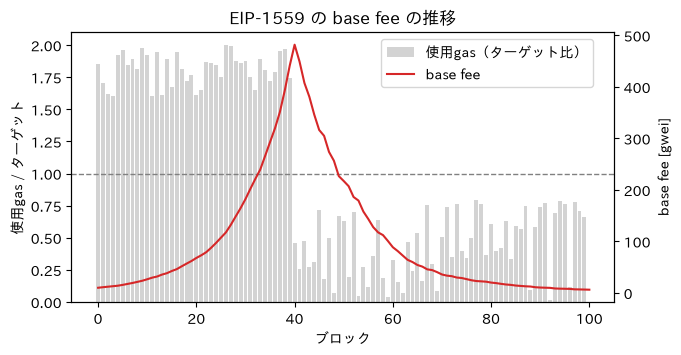

In [1]:
import matplotlib.pyplot as plt
import japanize_matplotlib  # noqa: F401
import numpy as np

GAS_TARGET = 1.0  # ターゲットを1とした相対値
rng = np.random.default_rng(0)

# 前半は混雑（ブロックがほぼ満杯）、後半は閑散
usage = np.concatenate([rng.uniform(1.6, 2.0, 40), rng.uniform(0.0, 0.8, 60)])
base_fee = [10.0]  # gwei
for g in usage:
    base_fee.append(base_fee[-1] * (1 + (g - GAS_TARGET) / GAS_TARGET / 8))

fig, ax1 = plt.subplots(figsize=(7, 3.5))
ax1.bar(range(len(usage)), usage, color="lightgray", label="使用gas（ターゲット比）")
ax1.axhline(1.0, color="gray", ls="--", lw=1)
ax1.set(xlabel="ブロック", ylabel="使用gas / ターゲット")
ax2 = ax1.twinx()
ax2.plot(base_fee, color="C3", label="base fee")
ax2.set_ylabel("base fee [gwei]")
fig.legend(loc="upper right", bbox_to_anchor=(0.88, 0.88))
ax1.set_title("EIP-1559 の base fee の推移")
plt.show()

### gas limitとintrinsic gas

トランザクションに必要なgasは実行してみるまで正確には分からないので、送信者は上限（gas limit）を指定する。ただし、実行前でも「最低限これだけは必要」という **intrinsic gas** は分かる。

- すべてのトランザクションに21,000 gas
- コントラクト作成ならさらに32,000 gas
- calldataのバイト数に応じたgas（ゼロバイトは4、非ゼロバイトは16 gas/バイト）

gas limitがintrinsic gasに満たないトランザクションは絶対に実行できないので、検証の段階で弾かれる。

### gas不足のとき

実行中にgas limitを使い切ると、トランザクションは **失敗（revert）** し、ステートの変更はすべて取り消される。ただし **消費したgas代は返ってこない**。失敗したトランザクションもブロックに含まれ、全ノードで「gas不足で失敗した」ことが検証される。

失敗してもgas代を取らないと、重い処理を投げて途中で失敗させるだけのスパムが可能になってしまうため。

## EVM（Ethereum Virtual Machine）

### 概要

**EVM** は、スマートコントラクトのバイトコードを実行する仮想マシン。すべてのフルノードが同じEVMで同じトランザクションを実行し、同じ結果（ステート）になることを確認しあう。

そのため、EVMは **決定論的** でなければならない。

- 浮動小数点演算がない（環境によって丸め誤差が異なりうるため）
- 真の乱数がない（ブロックのRANDAO値などで代用）
- 外部のネットワークやファイルにアクセスできない（外部データはオラクル経由で書き込む）

### アーキテクチャ

EVMは256bit（32バイト）のワードを単位とする **スタックマシン**。

| 領域 | 永続性 | 特徴 |
| --- | --- | --- |
| スタック | 実行中のみ | 最大1024要素。演算の中間値 |
| メモリ | 呼び出し中のみ | バイト単位でアクセスできる一時領域。拡張するとgasが二次関数的に増える |
| ストレージ | 永続 | 32バイトのキーと値のマップ。コントラクトの状態変数。読み書きが高い |
| transient storage | トランザクション中のみ | トランザクション終了時に消える（EIP-1153, 2024年〜）。再入防止のロックなどに使う |
| calldata | 読み取り専用 | トランザクションの入力データ |
| コード | 不変 | コントラクトのバイトコード（最大24,576バイト） |

スマートコントラクトは通常 **Solidity** などの高級言語で書き、コンパイルしたバイトコードをデプロイする（→[スマートコントラクト](./smart_contracts.ipynb)）。

```solidity
contract HelloWorld {
    function print() public pure returns (string memory) {
        return "Hello World!";
    }
}
```

これをコンパイルすると `6080604052348015...` のようなバイトコードになる。先頭の `60 80 60 40 52` は `PUSH1 0x80 PUSH1 0x40 MSTORE`（メモリ上の空き領域ポインタの初期化）で、Solidityが生成するほぼすべてのコントラクトの先頭に現れる。

### EVM互換チェーン

EVMの仕様とツールチェーン（Solidity、ウォレット、開発ツール）はEthereum以外でも広く採用されている。

- L2：Arbitrum, Optimism, Base, zkSync Era, Scroll など
- 他のL1：BNB Chain, Avalanche C-Chain, Polygon PoS など
- コンソーシアム・プライベート型：Hyperledger Besu, Quorum など

同じコントラクトのコードが、異なる信頼モデル（パブリック、コンソーシアム、プライベート）の上でそのまま動くことはEVMの大きな強み。

## トランザクションの実行

ブロック提案者（およびブロックを検証する全ノード）は、各トランザクションについて次の処理を行う。

1. 送信者のnonceを1増やす
2. `gas_limit × fee_per_gas` を送信者の残高から前払いで差し引く
3. 送金と、EVM上でのコントラクト実行を行い、ステートを更新する
4. 未使用gas分を払い戻す
5. base fee分を焼却し、priority fee分を提案者の `fee_recipient` に送る
6. 実行結果の **レシート** を作る

### レシートとイベント

レシートには実行結果が記録される。

| フィールド | 内容 |
| --- | --- |
| status | 成功なら1、失敗なら0 |
| cumulative_gas_used | ブロック内でそのトランザクションまでに使われたgasの累計 |
| logs | コントラクトが発行（emit）したイベントの記録 |
| logs_bloom | logsを高速に検索するためのBloomフィルター |

コントラクトはイベント（ログ）を発行でき、DAppsのフロントエンドやインデクサーはこれを監視してオンチェーンの出来事を検知する。ログはコントラクトからは読めないが、ストレージより安く記録できる。

## ブロック

### ブロックヘッダーの主なフィールド

| フィールド | 内容 |
| --- | --- |
| parentHash | 親ブロックのハッシュ（Keccak-256を1回） |
| stateRoot | ブロック内の全トランザクション実行後のワールドステートのルート |
| transactionsRoot | ブロック内のトランザクションのMPTのルート |
| receiptsRoot | ブロック内のレシートのMPTのルート |
| logsBloom | ブロック内の全ログのBloomフィルター |
| gasLimit | ブロック全体のgas上限 |
| gasUsed | ブロック内のトランザクションの使用gasの合計 |
| baseFeePerGas | このブロックのbase fee |
| feeRecipient | priority feeの受取アドレス |
| withdrawalsRoot | ステーキングの引き出し情報のルート（Shapella以降） |

ブロックの容量はバイト数ではなく **gas上限** で決まる。提案者は、gas上限に収まる範囲で、priority feeの高いトランザクションを選んで詰める。

ブロックのgas上限は、2021年から長らく3,000万gasだったが、2025年に段階的に引き上げられ、6,000万gasになった。

### ブロックの検証

ブロックを受け取ったノードは、構造・署名・gasの整合性などに加えて、**ブロック内の全トランザクションを自分でも実行し**、得られたstateRoot・receiptsRootがヘッダーの値と一致するかを確認する。

一致すれば、提案者が正しく計算したことが分かる。「他人の計算結果を信用せず、自分で再計算して答え合わせする」ことがEthereumの安全性の土台になっている。

## ノードとクライアント

| ノードの種類 | 保持するデータ | ストレージの目安 |
| --- | --- | --- |
| ライトノード | ブロックヘッダーのみ | 小 |
| フルノード | 全ブロックと直近のステート（古いステートは削除） | 1〜2TB |
| アーカイブノード | 全ブロックと、全時点のステート | 十数TB以上 |

PoS移行後、フルノードを動かすには **実行クライアント（Execution Client）** と **コンセンサスクライアント（Consensus Client）** の両方が必要になった。

| 種類 | 役割 | 主な実装 |
| --- | --- | --- |
| 実行クライアント | トランザクションの実行、ステートの管理 | Geth（Go）, Nethermind（C#）, Besu（Java）, Erigon（Go）, Reth（Rust） |
| コンセンサスクライアント | PoSの合意形成、バリデータの管理 | Lighthouse（Rust）, Prysm（Go）, Teku（Java）, Nimbus（Nim）, Lodestar（TypeScript） |

複数の独立した実装が存在する **クライアント多様性（client diversity）** は、1つの実装にバグがあってもネットワーク全体が止まったり誤った状態に確定したりしないために重要とされている。